# Titanic Survival Prediction using K-Nearest Neighbors (KNN)

In this notebook we will build a model that predicts whether a passenger **survived** the Titanic disaster, using the **K-Nearest Neighbors (KNN)** algorithm.

## What is KNN?

**K-Nearest Neighbors** is one of the simplest machine learning algorithms. It is a **lazy learner** — it doesn't really *learn* a model during training. Instead, it just memorizes the entire training set.

When asked to predict the class of a new data point, KNN:

1. Calculates the **distance** (usually Euclidean) from the new point to every point in the training set.
2. Picks the **K nearest** points (the neighbors).
3. Takes a **majority vote** of those K neighbors' labels.
4. Returns that label as the prediction.

### Why is feature scaling important for KNN?

Because KNN relies on **distance**, features with large numeric ranges (like `fare` 0–500) will dominate features with small ranges (like `pclass` 1–3). So we MUST scale the features before training.

## Load the dataset

In [1]:
import pandas as pd
df = pd.read_csv(r'/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/KNN/titanic 1.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.shape

(891, 15)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Column meanings

| Column | Meaning |
|---|---|
| `survived` | 0 = died, 1 = survived (**target**) |
| `pclass`   | Passenger class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| `sex`      | male / female |
| `age`      | Age in years |
| `sibsp`    | # of siblings / spouses aboard |
| `parch`    | # of parents / children aboard |
| `fare`     | Ticket fare |
| `embarked` | Port of embarkation: S=Southampton, C=Cherbourg, Q=Queenstown |
| `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone` | Redundant or mostly-null helper columns |

## Drop redundant / leaky columns

- `alive` is literally the same thing as `survived` (yes/no version) → **data leakage**, must drop.
- `class`, `who`, `adult_male`, `embark_town` duplicate info already present in `pclass`, `sex`, `age`, `embarked`.
- `deck` has too many missing values (~77%) → drop.
- `alone` is derivable from `sibsp + parch` → drop to keep it simple.

In [6]:
df = df.drop(columns=['alive', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Handle missing values

- `age` has ~177 missing values → fill with the **median** age (robust to outliers).
- `embarked` has only 2 missing values → fill with the **mode** (most common port).

In [7]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [8]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 116


## EDA (Exploratory Data Analysis)

In [9]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

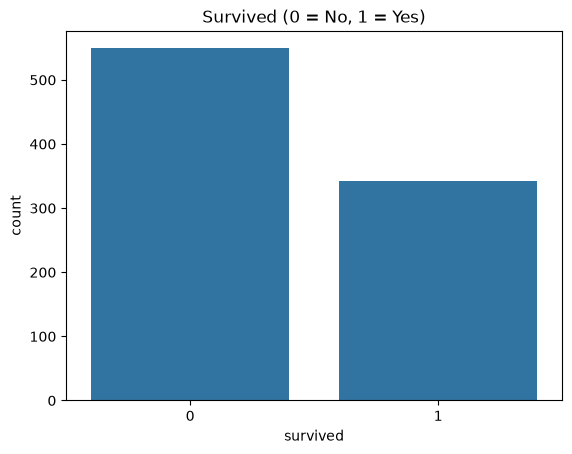

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='survived')
plt.title('Survived (0 = No, 1 = Yes)')
plt.show()

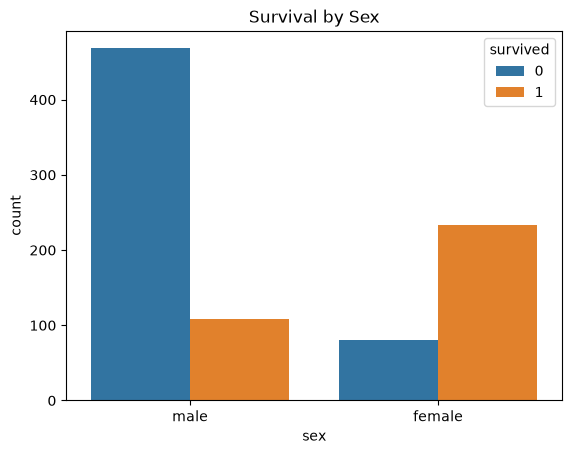

In [11]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Sex')
plt.show()

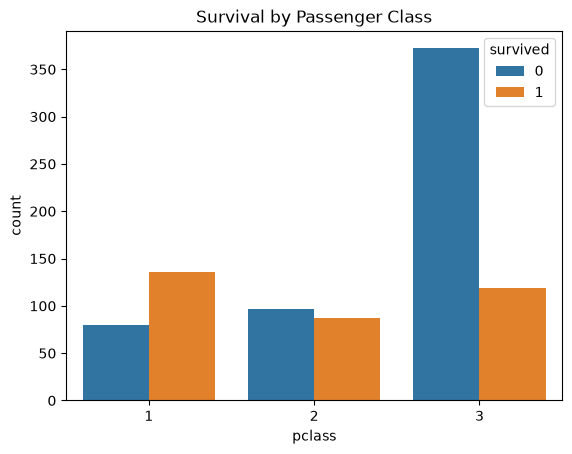

In [12]:
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Survival by Passenger Class')
plt.show()

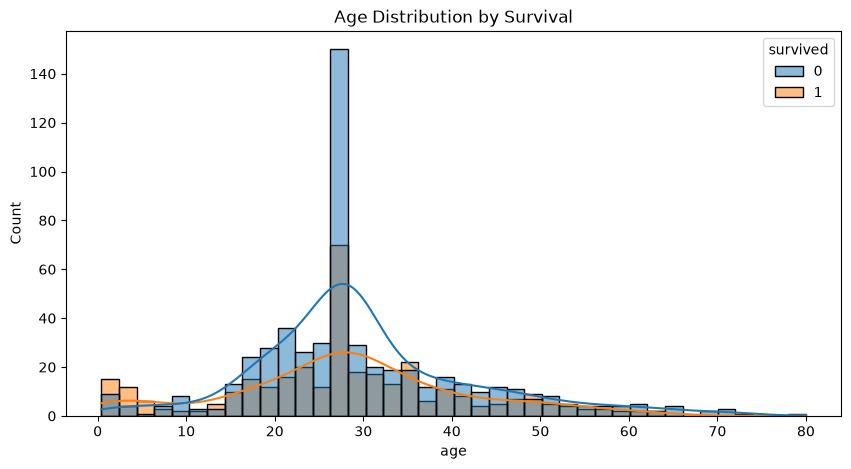

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='survived', bins=40, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

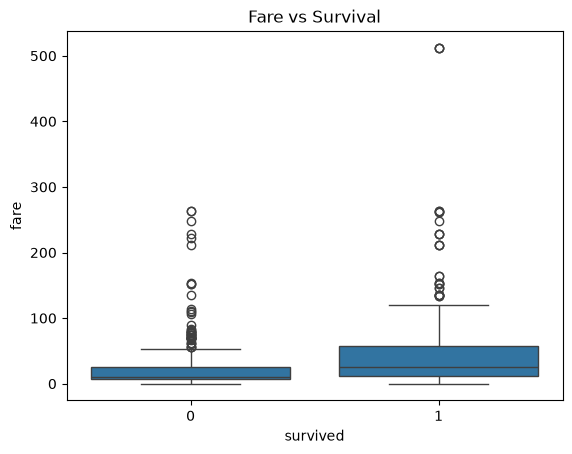

In [14]:
sns.boxplot(data=df, x='survived', y='fare')
plt.title('Fare vs Survival')
plt.show()

**Observations:**

- **Females** survived at a much higher rate than males.
- **1st class** passengers had the highest survival rate; **3rd class** the lowest.
- **Children** (low age) had slightly better survival rates.
- Passengers who paid **higher fares** (richer passengers) survived more often.

## Encode categorical variables

KNN works with numbers only, so we need to convert text categories into numbers.

- `sex` → 0 / 1 (binary, simple mapping)
- `embarked` → one-hot encoded (3 categories: S, C, Q → 3 columns)

In [15]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [16]:
df = pd.get_dummies(df, columns=['embarked'], drop_first=False, dtype=int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


## Split into features (X) and target (y), then train/test split

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1,
                                                    stratify=y)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (623, 9)
Test shape : (268, 9)


## Feature Scaling (CRITICAL for KNN)

KNN uses distance between points. If `fare` ranges from 0 to 500 while `sex` is 0 or 1, then `fare` will completely dominate the distance calculation and `sex` will be ignored.

We use **StandardScaler** which transforms each feature to have:
- Mean = 0
- Std deviation = 1

> **Important:** We `fit` the scaler ONLY on training data, then `transform` both train and test using that same scaler. Never fit on test data — that would leak information.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('First scaled training row:\n', X_train_scaled[0])

First scaled training row:
 [-0.37070996  1.35344678  0.31429548  0.41029638  2.01370711 -0.08477977
 -0.48085892 -0.29859812  0.60764362]


## Train the KNN model

We start with `k = 5` (a common default).

In [20]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [22]:
for actual, pred in list(zip(y_test[:10], y_pred[:10])):
    a = 'Survived' if actual == 1 else 'Died'
    p = 'Survived' if pred == 1 else 'Died'
    print(f'Actual: {a:10s} | Predicted: {p}')

Actual: Died       | Predicted: Died
Actual: Died       | Predicted: Died
Actual: Died       | Predicted: Died
Actual: Survived   | Predicted: Survived
Actual: Survived   | Predicted: Survived
Actual: Died       | Predicted: Died
Actual: Died       | Predicted: Died
Actual: Survived   | Predicted: Survived
Actual: Died       | Predicted: Survived
Actual: Died       | Predicted: Died


In [23]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (k=5): {accuracy:.4f}')

Accuracy (k=5): 0.7761


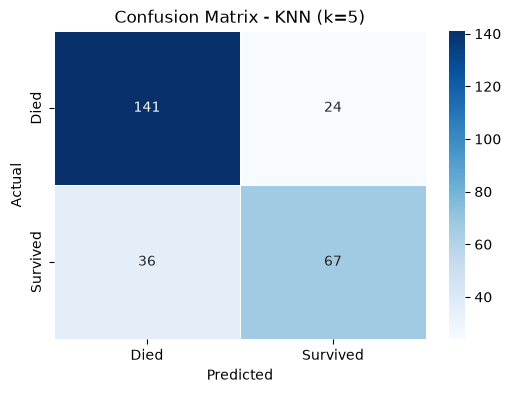

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix - KNN (k=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

              precision    recall  f1-score   support

        Died       0.80      0.85      0.82       165
    Survived       0.74      0.65      0.69       103

    accuracy                           0.78       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.78      0.77       268



## Elbow Method to Choose K

The **Elbow Method** is a visual technique used to pick a good value of **K**.

Instead of plotting *accuracy*, we plot the **error rate** (`1 - accuracy`) for each value of K and look for the **"elbow"** — the point where the error stops dropping sharply and starts to level off.

- **Before the elbow** → adding more neighbors **significantly reduces** the error.
- **After the elbow** → adding more neighbors gives **diminishing returns** (and the model may start to underfit).

The K at the elbow is usually a good trade-off between **bias** (too smooth) and **variance** (too noisy).

In [26]:
error_rates = []
k_values = range(1, 21)

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, pred))

elbow_k = k_values[error_rates.index(min(error_rates))]
print(f'K with the lowest error = {elbow_k}  (error rate = {min(error_rates):.4f})')

K with the lowest error = 16  (error rate = 0.1754)


In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 21)
cv_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train,
                             cv=5, scoring='accuracy')
    cv_errors.append(1 - scores.mean())

best_k = k_values[cv_errors.index(min(cv_errors))]
print("Best K:", best_k)

Best K: 11


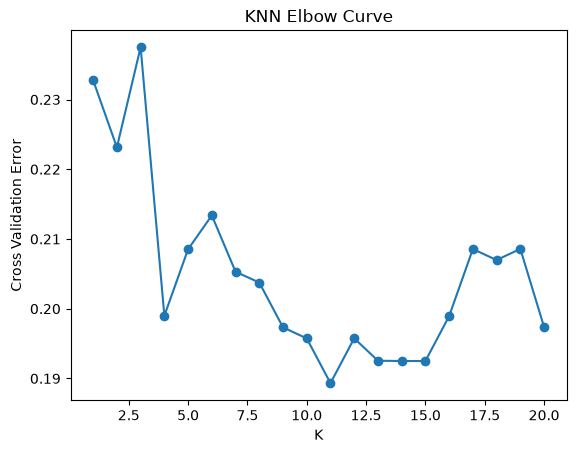

In [28]:
plt.plot(k_values, cv_errors, marker='o')
plt.xlabel("K")
plt.ylabel("Cross Validation Error")
plt.title("KNN Elbow Curve")
plt.show()

**How to read the chart:**

Look at where the curve **bends sharply** and then **flattens out** — that bend is the *elbow*. Picking K near the elbow gives a model that is accurate without being overly complex (small K) or overly smooth (large K).

In this case the elbow K matches the K we found earlier with the accuracy plot, which confirms our choice.

## Retrain with the best K

In [29]:
final_model = KNeighborsClassifier(n_neighbors=elbow_k )
final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)

print(f'Final Accuracy (k={elbow_k}): {accuracy_score(y_test, y_pred_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Died', 'Survived']))

Final Accuracy (k=16): 0.8246

              precision    recall  f1-score   support

        Died       0.82      0.92      0.87       165
    Survived       0.83      0.68      0.75       103

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.83      0.82      0.82       268



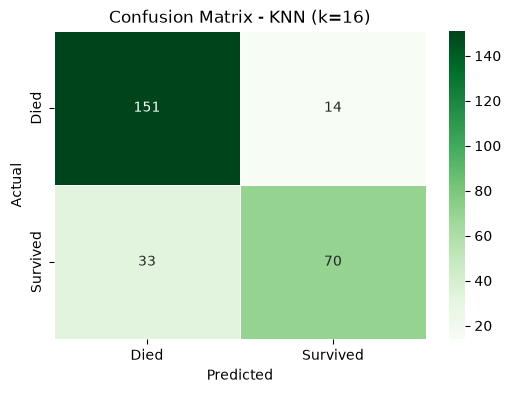

In [30]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            linewidths=0.5)
plt.title(f'Confusion Matrix - KNN (k={elbow_k })')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Conclusion

- **KNN** classified Titanic survivors with reasonable accuracy (~75–80% depending on K).
- The **most important steps** were:
  1. Handling missing values (age, embarked)
  2. Encoding categorical features (sex, embarked)
  3. **Scaling features** with `StandardScaler` (mandatory for KNN!)
  4. Tuning **K** by trying multiple values
- KNN clearly captured the famous *"women and children first"* pattern, and that **1st-class passengers** had a much better chance of survival.
- For further improvement we could try **weighted KNN** (`weights='distance'`), use **GridSearchCV** with cross-validation, or compare against **Logistic Regression** / **Random Forest**.